# ANÁLISE EXPLORATÓRIA DOS DADOS + TREINAÇÃO E TESTE DO MODELO DE CLASSIFICAÇÃO

---

**Este notebook apresenta uma análise exploratória dos dados ESG GOLD (dados já tratados), com o objetivo de compreender o comportamento das variáveis e subsidiar a definição do modelo mais adequado para implementação em produção (deploy).**

---

**DICIONÁRIO DA BASE GOLD:**

| Coluna                         | Tipo        | Descrição                                                                 |
|--------------------------------|-------------|---------------------------------------------------------------------------|
| empresa                        | Texto       | Nome da empresa participante da análise ESG                              |
| cnpj                           | Texto       | Identificador único da empresa (CNPJ simplificado ou anonimizado)        |
| qtd_colaboradores              | Numérico    | Quantidade de colaboradores da empresa                                   |
| faturamento_anual              | Numérico    | Faixa ou valor do faturamento anual                                      |
| possui_processos_legais        | Binário     | Indica se a empresa possui processos legais                              |
| recebeu_sancao                 | Binário     | Indica se a empresa já recebeu sanções                                   |
| trabalho_digno                 | Binário     | Indica práticas relacionadas a trabalho digno                            |
| possui_certificacoes           | Binário     | Indica se a empresa possui certificações relevantes                      |
| possui_politica_esg            | Binário     | Indica se a empresa possui política ESG formalizada                      |
| treinamento_sustentabilidade   | Binário     | Indica se há treinamentos em sustentabilidade                            |
| possui_compliance              | Binário     | Indica existência de área/processos de compliance                        |
| controla_impactos_ambientais   | Binário     | Indica controle de impactos ambientais                                   |
| gestao_agua                    | Binário     | Indica práticas de gestão de água                                        |
| eficiencia_energetica          | Binário     | Indica ações de eficiência energética                                    |
| gerenciamento_residuos         | Binário     | Indica práticas de gestão de resíduos                                    |
| calcula_pegada_carbono         | Binário     | Indica se a empresa calcula sua pegada de carbono                        |
| inventario_auditado            | Binário     | Indica se há inventário auditado (ex: emissões, processos)               |
| possui_diversidade             | Binário     | Indica políticas ou ações de diversidade                                 |
| possui_voluntariado            | Binário     | Indica programas de voluntariado                                         |
| possui_saude_mental            | Binário     | Indica iniciativas de saúde mental para colaboradores                    |
| compras_sustentaveis           | Binário     | Indica adoção de compras sustentáveis                                    |
| criterio_fornecedores          | Binário     | Indica critérios ESG na seleção de fornecedores                          |
| clausulas_esg_fornecedores     | Binário     | Indica cláusulas ESG em contratos com fornecedores                       |
| treinamento_fornecedores       | Binário     | Indica treinamento ESG para fornecedores                                 |
| diversidade_fornecedores       | Binário     | Indica incentivo à diversidade na base de fornecedores                   |
| auditoria_fornecedores         | Binário     | Indica auditorias em fornecedores                                        |
| dados_confirmados              | Texto       | Indica se os dados foram confirmados (ex: "Sim" ou "Não")                |
| tempo_preenchimento_min        | Numérico    | Tempo de preenchimento do questionário (em minutos)                      |
| porte_x_faturamento            | Numérico    | Indicador derivado cruzando porte da empresa com faturamento             |
| total_praticas_esg             | Numérico    | Quantidade total de práticas ESG adotadas                                |
| score_governanca               | Numérico    | Score referente ao pilar de governança                                   |
| score_social                   | Numérico    | Score referente ao pilar social                                          |
| score_ambiental                | Numérico    | Score referente ao pilar ambiental                                       |
| score_cadeia                   | Numérico    | Score referente à cadeia de fornecedores                                 |
| score_esg_total                | Numérico    | Score ESG consolidado                                                    |
| maturidade_esg                 | Texto       | Classificação da maturidade ESG (ex: baixa, média, alta)                 |

- IMPORTS
---

In [1]:
# Manipulação de dados e plots
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option(
    "display.max_columns", 
    None
)

# Divisão de dados, modelos ML e métricas de avaliação
from sklearn.model_selection import (
    cross_val_predict, 
    StratifiedKFold, 
    LeaveOneOut,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    precision_score, 
    confusion_matrix,
    ConfusionMatrixDisplay
)

- ANÁLISE EXPLORATÓRIA
---

In [2]:
df = pd.read_csv("../data/gold/ESGreportingGOLD.csv")
display(df.head())
df.info()

,empresa,cnpj,qtd_colaboradores,faturamento_anual,possui_processos_legais,recebeu_sancao,trabalho_digno,possui_certificacoes,possui_politica_esg,treinamento_sustentabilidade,possui_compliance,controla_impactos_ambientais,gestao_agua,eficiencia_energetica,gerenciamento_residuos,calcula_pegada_carbono,inventario_auditado,possui_diversidade,possui_voluntariado,possui_saude_mental,compras_sustentaveis,criterio_fornecedores,clausulas_esg_fornecedores,treinamento_fornecedores,diversidade_fornecedores,auditoria_fornecedores,dados_confirmados,tempo_preenchimento_min,porte_x_faturamento,total_praticas_esg,score_governanca,score_social,score_ambiental,score_cadeia,score_esg_total,maturidade_esg
0,Ltda. - Marca Modelo 01,191,0.0,2.0,1,0,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,0,1,1,18.0,0.0,19,0.83,0.83,0.67,1.00,0.81,alta
1,S.A. - Plataforma Modelo 02,272,1.0,3.0,1,0,1,0,1,1,1,1,0,1,0,0,0,0,0,1,0,1,1,0,1,0,1,25.0,3.0,12,0.67,0.50,0.33,0.50,0.50,media
2,Tecnologia Ltda. - Solução Modelo 03,353,2.0,4.0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,0,0,1,1,1,0,1,1,32.0,8.0,17,0.50,0.50,0.83,0.75,0.64,media
3,Serviços Digitais Ltda. - Operação Modelo 04,434,3.0,0.0,1,0,1,0,1,0,1,0,0,1,1,0,0,1,1,1,0,1,0,0,0,0,1,39.0,0.0,11,0.67,0.50,0.33,0.25,0.46,baixa
4,Consultoria Ltda. - Marca Modelo 05,515,0.0,2.0,1,0,1,1,0,1,0,1,0,0,1,1,0,1,1,1,1,1,1,1,1,0,1,46.0,0.0,16,0.50,1.00,0.50,0.75,0.66,alta


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   empresa                       55 non-null     object 
 1   cnpj                          55 non-null     object 
 2   qtd_colaboradores             55 non-null     float64
 3   faturamento_anual             55 non-null     float64
 4   possui_processos_legais       55 non-null     int64  
 5   recebeu_sancao                55 non-null     int64  
 6   trabalho_digno                55 non-null     int64  
 7   possui_certificacoes          55 non-null     int64  
 8   possui_politica_esg           55 non-null     int64  
 9   treinamento_sustentabilidade  55 non-null     int64  
 10  possui_compliance             55 non-null     int64  
 11  controla_impactos_ambientais  55 non-null     int64  
 12  gestao_agua                   55 non-null     int64  
 13  eficien

In [3]:
# Ajustando target
df["maturidade_esg"] = df["maturidade_esg"].map({
    "baixa": 0,
    "media": 1, 
    "alta": 2
})

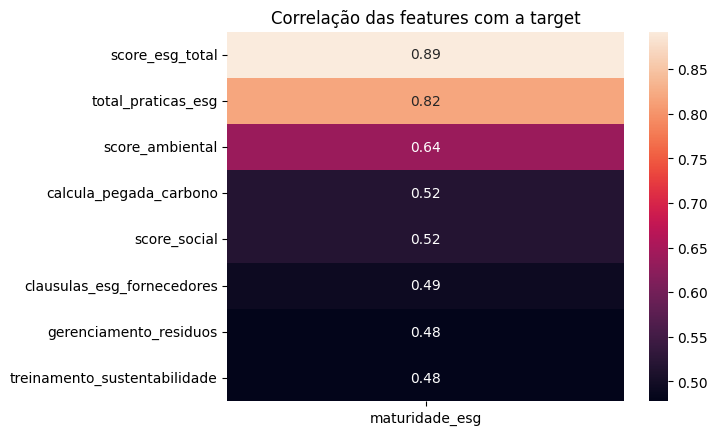

In [4]:
# Analisando correlação de target com as features
corr = df.drop(columns=["empresa", "cnpj"]).corr()["maturidade_esg"]
corr_filtrado = corr[abs(corr) > 0.4].sort_values(ascending=False).drop("maturidade_esg").to_frame()

plt.title("Correlação das features com a target")
sns.heatmap(corr_filtrado, annot=True)
plt.show()

**Análise:** É possível ver em que praticamente a maioria das colunas que tem maior correlação com a target, são as colunas criadas na etapa GOLD. Isso acontece, porque a target é criada justamente com base na coluna `score_esg_total`, que é uma média das colunas criadas por pilares. Para treinar o modelo, devo retirar as features que fiz. Isso pode afetar o modelo, pois, isso resulta em *Dataleakege*. Irei veirificar o mesmo gráfico, porém sem as colunas criadas.

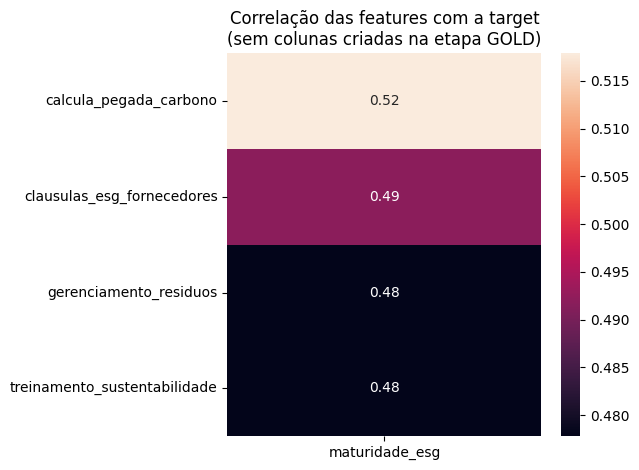

In [5]:
# Analisando correlação da target com as features
corr = df.drop(columns=[
    "empresa",
    "cnpj",
    "porte_x_faturamento",
    "total_praticas_esg",
    "score_governanca",
    "score_social",
    "score_ambiental",
    "score_cadeia",
    "score_esg_total",
]).corr()["maturidade_esg"]

corr_filtrado = (
    corr[abs(corr) > 0.4]
    .sort_values(ascending=False)
    .drop("maturidade_esg")
    .to_frame()
)

plt.title("Correlação das features com a target\n(sem colunas criadas na etapa GOLD)")
sns.heatmap(corr_filtrado, annot=True)
plt.tight_layout()
plt.show()

**Análise:** Apesar das correlações não serem muito altas, elas já indicam padrões relevantes. Práticas como cálculo da pegada de carbono, gerenciamento de resíduos, cláusulas ESG para fornecedores e treinamentos em sustentabilidade estão mais associadas a empresas com maior maturidade ESG. Isso mostra que já é possível ter uma boa noção do nível de maturidade da empresa a partir dessas práticas sustentáveis.

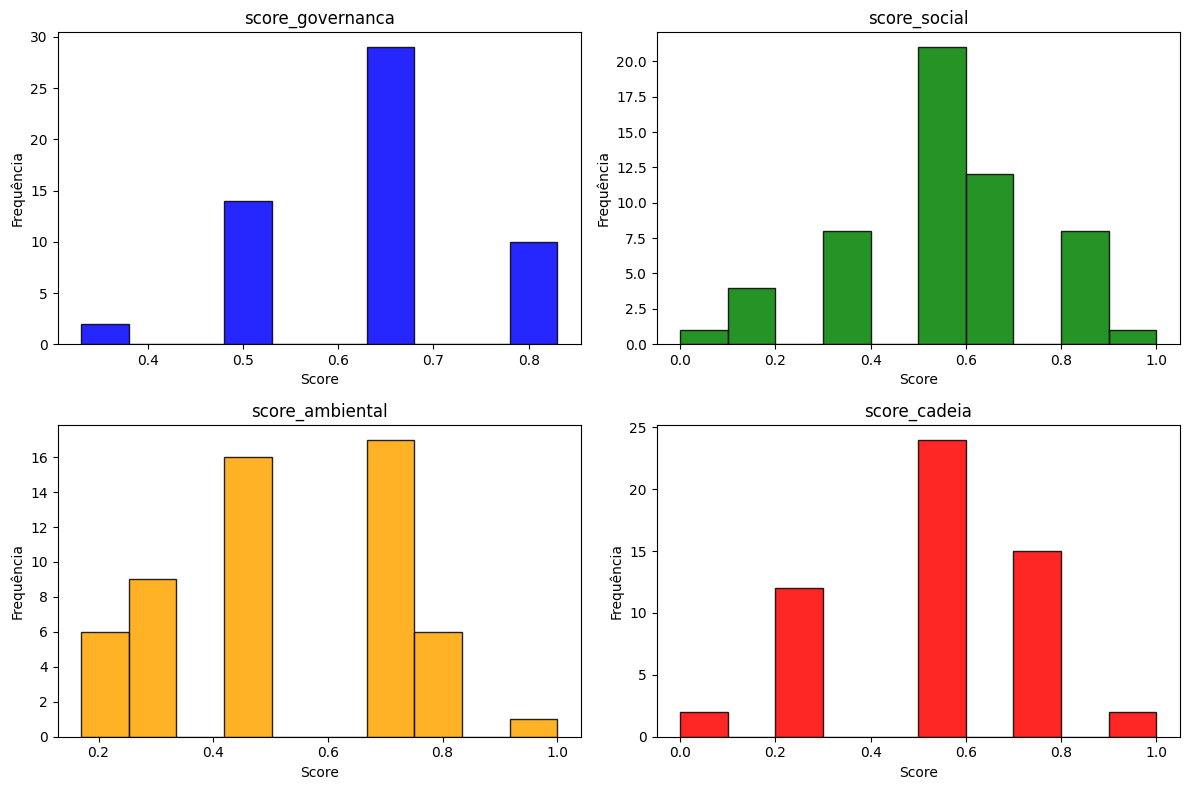

In [6]:
# Analisando distribuição do score de cada pilar ESG
cols = [
    "score_governanca",
    "score_social",
    "score_ambiental",
    "score_cadeia",
]

colors = ["blue", "green", "orange", "red"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(
        df[col].dropna(),
        bins=10,
        color=colors[i],
        alpha=0.85,
        edgecolor="black"
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [7]:
# Estatísticas descritivas de cada pilar
df[["score_governanca",
    "score_social",
    "score_ambiental",
    "score_cadeia"]].describe()

,score_governanca,score_social,score_ambiental,score_cadeia
count,55.000000,55.000000,55.000000,55.000000
mean,0.643455,0.536364,0.533818,0.513636
std,0.125687,0.206921,0.203911,0.222664
min,0.330000,0.000000,0.170000,0.000000
25%,0.500000,0.500000,0.330000,0.375000
50%,0.670000,0.500000,0.500000,0.500000
75%,0.670000,0.670000,0.670000,0.750000
max,0.830000,1.000000,1.000000,1.000000


**Análise:** Observando os gráficos e a tabela descritiva, é possível ver que as distribuições dos pilares ESG são bastante semelhantes, com destaque para a governança, que apresenta mediana acima de 0,60. Isso indica que as empresas tendem a ser mais maduras em práticas de governança, provavelmente por serem mais exigidas por regulações e investidores. Já os pilares social e ambiental apresentam valores mais baixos e maior variabilidade, sugerindo uma adoção menos consistente dessas práticas entre as empresas. De forma geral, os dados indicam um cenário de maturidade ESG ainda desequilibrado, com maior avanço em governança em comparação aos demais pilares.

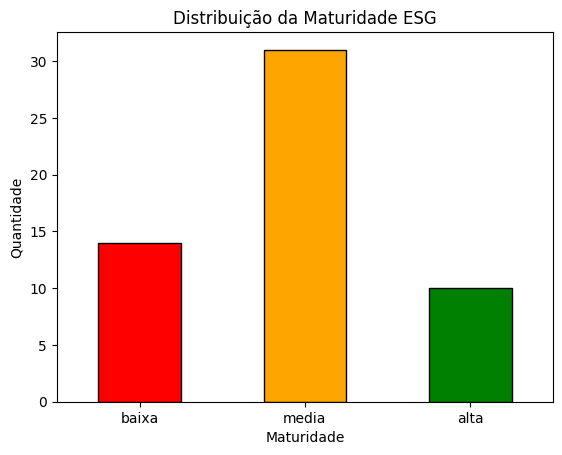

In [8]:
# Analisando distribuição de maturidade ESG
mapa = {
    0: "baixa",
    1: "media",
    2: "alta"
}
serie = df["maturidade_esg"].map(mapa).value_counts().reindex(["baixa", "media", "alta"])
cores = ["red", "orange", "green"]
serie.plot(
    kind="bar",
    color=cores,
    edgecolor="black"
)

plt.title("Distribuição da Maturidade ESG")
plt.xlabel("Maturidade")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

In [9]:
# Pct do desbalanceamento
df_pct = (df["maturidade_esg"].value_counts(normalize=True).rename(index={
        0: "baixa",
        1: "media",
        2: "alta"
    }).reset_index()
)
df_pct["proportion"] = (df_pct["proportion"] * 100).round(0).astype(str) + "%"
df_pct

,maturidade_esg,proportion
0,media,56.0%
1,baixa,25.0%
2,alta,18.0%


**Análise:** A distribuição da maturidade ESG indica que a maioria das empresas está na categoria média, sugerindo um estágio intermediário de adoção de práticas ESG. Em seguida, aparecem as empresas com maturidade baixa, representando uma parcela relevante ainda em fase inicial de desenvolvimento. Já a categoria alta é a menos frequente, mostrando que poucas empresas atingiram um nível mais avançado de maturidade ESG. Em geral, o cenário evidencia predominância de maturidade intermediária, com menor presença de casos avançados. Já em questão do desbalanceamento, não é um desbalanceamento “extremo”, mas pode ser suficientemente desbalanceado para afetar bastante o modelo criado, principalmente em multiclasse.

Após entender melhor sobre meu conjunto de dados, irei partir para a construção do modelo de previsão. Farei todas as etapas e testes necessários para a criação do modelo:
- *Divisão dos dados* 
- *Criação de modelos*
- *Treinos e Testes* 
- *Validando com métricas apropriadas*  

- CRIANDO MODELO ML (PREVISÃO MATURIDADE ESG)
---

Para iniciar a avaliação, serão utilizados os 10 primeiros registros do dataset como conjunto de teste, por representarem os dados reais. Os demais registros foram gerados por LLM e serão utilizados no processo de treino. O objetivo é verificar se o modelo consegue generalizar bem para dados reais mesmo tendo sido treinado parcialmente com dados sintéticos.

Para a validação do modelo, serão utilizadas duas técnicas: Leave-One-Out (LOO) e Stratified K-Fold, ambas adequadas para conjuntos de dados pequenos. O LOO permite uma avaliação mais granular, utilizando quase todos os dados para treino em cada iteração, enquanto o Stratified K-Fold garante que a proporção das classes seja preservada em cada divisão, o que é importante para problemas de classificação.

O desempenho do modelo será avaliado através de: **Matriz de Consfusão**, **Acurácia**, **Recall** e **Precisão**.

In [10]:
# Definindo base que vamos treinar e base que vamos utilizar para testar
df_test = df.iloc[0:10].drop(columns=["cnpj", "empresa"])
df_train = df.iloc[11:].drop(columns=["cnpj", "empresa"])

In [11]:
# Divisão das features e target (de treino e teste)
x = df_train.drop(columns=df_train.columns[27:])
y = df_train.maturidade_esg

x_df_test = df_test.drop(columns=df_test.columns[27:])
y_df_test = df_test.maturidade_esg

Para os modelos, serão utilizados 3 algoritmos preditivos de classificação:
- `XGBoost` -> Modelo ensemble baseado em gradient boosting de árvores de decisão
- `KNN` -> Modelo baseado em distância euclidiana
- `Decision Tree` -> Modelo baseado em árvore de decisão

In [12]:
# Definindo modelos que irei usar (para StratifiedKfold)
xgb_skf = XGBClassifier(
    n_estimators=10,
    max_depth=5,
    learning_rate=0.3

)
tree_skf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=3
)
knn_skf = KNeighborsClassifier(
    n_neighbors=7,
    metric="euclidean"
)

=========== XGBOOST ===========
Acurácia : 0.7045
Precisão : 0.7045
Recall   : 0.5726

=========== DECISION TREE ===========
Acurácia : 0.5227
Precisão : 0.4443
Recall   : 0.4573

=========== KNN ===========
Acurácia : 0.5455
Precisão : 0.2929
Recall   : 0.3376 



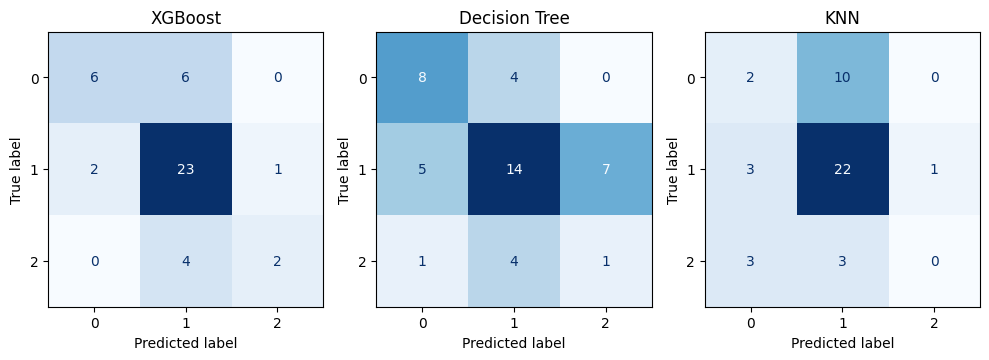

In [13]:
# Analisando desempenho dos modelos (treino e teste com cross_val_predict)
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# XGBoost
xgb_skf_pred = cross_val_predict(xgb_skf, x, y, cv=skf)
tree_skf_pred = cross_val_predict(tree_skf, x, y, cv=skf)
knn_skf_pred = cross_val_predict(knn_skf, x, y, cv=skf)

acc_xgb_skf = accuracy_score(y, xgb_skf_pred)
precision_xgb_skf = precision_score(y, xgb_skf_pred, average="macro")
recall_xgb_skf = recall_score(y, xgb_skf_pred, average="macro")

# Árvore de Decisão
acc_tree_skf = accuracy_score(y, tree_skf_pred)
precision_tree_skf = precision_score(y, tree_skf_pred, average="macro")
recall_tree_skf = recall_score(y, tree_skf_pred, average="macro")

# KNN
acc_knn_skf = accuracy_score(y, knn_skf_pred)
precision_knn_skf = precision_score(y, knn_skf_pred, average="macro")
recall_knn_skf = recall_score(y, knn_skf_pred, average="macro")


print("=========== XGBOOST ===========")
print("Acurácia :", round(acc_xgb_skf, 4))
print("Precisão :", round(precision_xgb_skf, 4))
print("Recall   :", round(recall_xgb_skf, 4))

print("\n=========== DECISION TREE ===========")
print("Acurácia :", round(acc_tree_skf, 4))
print("Precisão :", round(precision_tree_skf, 4))
print("Recall   :", round(recall_tree_skf, 4))

print("\n=========== KNN ===========")
print("Acurácia :", round(acc_knn_skf, 4))
print("Precisão :", round(precision_knn_skf, 4))
print("Recall   :", round(recall_knn_skf, 4), "\n")

# Matrizes de confusão
cm_xgb = confusion_matrix(y, xgb_skf_pred)
cm_tree = confusion_matrix(y, tree_skf_pred)
cm_knn = confusion_matrix(y, knn_skf_pred)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

ConfusionMatrixDisplay(cm_xgb).plot(
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("XGBoost")

ConfusionMatrixDisplay(cm_tree).plot(
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(cm_knn).plot(
    cmap="Blues",
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("KNN")

plt.tight_layout()
plt.show()

**Análise:** Pelas métricas apresentadas de cada modelo, fica óbvio que o `XGBoost` se saiu melhor, tanto na acurácia quanto no F1. Foi testado as melhores combinações tanto do Kfold quando dos hiperparâmetros de cada modelo (dei mais ênfase ao XGBoost, pois se saiu bem melhor que os outros). A melhor combinação foi justamente utilizando um **Kfold=5** e essas combinações de hiperparâmetros: **n_estimators=10, max_depth=5, learning_rate=0.3**. A seguir será  o treino e teste utilizando Leave-One-Out para divisão dos dados. 

In [14]:
# Definindo modelos que irei usar (para StratifiedKfold)
xgb_loo = XGBClassifier(
    n_estimators=8,
    max_depth=6,
    learning_rate=0.3

)
tree_loo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=3
)
knn_loo = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

=========== XGBOOST ===========
Acurácia : 0.75
Precisão : 0.835
Recall   : 0.6132

=========== DECISION TREE ===========
Acurácia : 0.7045
Precisão : 0.5062
Recall   : 0.5171

=========== KNN ===========
Acurácia : 0.4773
Precisão : 0.3996
Recall   : 0.3996 



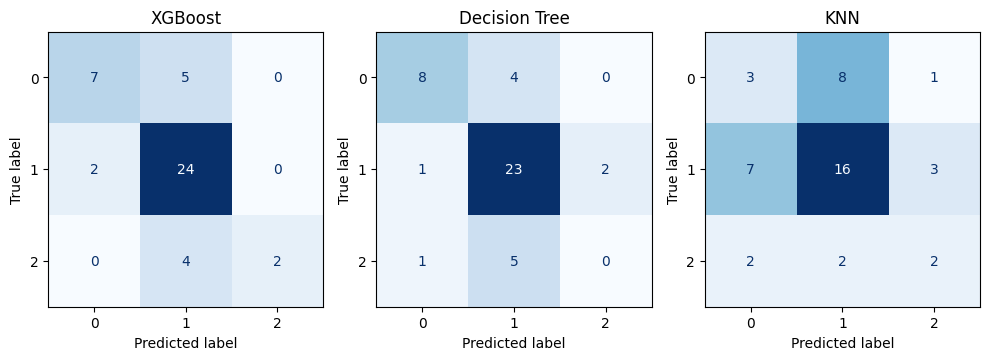

In [15]:
# Analisando desempenho dos modelos (treino e teste com cross_val_predict) com Leave-One-Out
loo = LeaveOneOut()

# XGBoost
xgb_loo_pred = cross_val_predict(xgb_loo, x, y, cv=loo)
tree_loo_pred = cross_val_predict(tree_loo, x, y, cv=loo)
knn_loo_pred = cross_val_predict(knn_loo, x, y, cv=loo)

acc_xgb_loo = accuracy_score(y, xgb_loo_pred)
precision_xgb_loo = precision_score(y, xgb_loo_pred, average="macro")
recall_xgb_loo = recall_score(y, xgb_loo_pred, average="macro")

# Árvore de Decisão
acc_tree_loo = accuracy_score(y, tree_loo_pred)
precision_tree_loo = precision_score(y, tree_loo_pred, average="macro")
recall_tree_loo = recall_score(y, tree_loo_pred, average="macro")

# KNN
acc_knn_loo = accuracy_score(y, knn_loo_pred)
precision_knn_loo = precision_score(y, knn_loo_pred, average="macro")
recall_knn_loo = recall_score(y, knn_loo_pred, average="macro")


print("=========== XGBOOST ===========")
print("Acurácia :", round(acc_xgb_loo, 4))
print("Precisão :", round(precision_xgb_loo, 4))
print("Recall   :", round(recall_xgb_loo, 4))

print("\n=========== DECISION TREE ===========")
print("Acurácia :", round(acc_tree_loo, 4))
print("Precisão :", round(precision_tree_loo, 4))
print("Recall   :", round(recall_tree_loo, 4))

print("\n=========== KNN ===========")
print("Acurácia :", round(acc_knn_loo, 4))
print("Precisão :", round(precision_knn_loo, 4))
print("Recall   :", round(recall_knn_loo, 4), "\n")

# Matrizes de confusão
cm_xgb = confusion_matrix(y, xgb_loo_pred)
cm_tree = confusion_matrix(y, tree_loo_pred)
cm_knn = confusion_matrix(y, knn_loo_pred)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

ConfusionMatrixDisplay(cm_xgb).plot(
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("XGBoost")

ConfusionMatrixDisplay(cm_tree).plot(
    cmap="Blues",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(cm_knn).plot(
    cmap="Blues",
    ax=axes[2],
    colorbar=False
)
axes[2].set_title("KNN")

plt.tight_layout()
plt.show()

**Análise:** Fazendo a divisão de dados através da técnica, Leave-One-Out, os modelos (XGBoost e Árvore de Decisão) já mostram uma melhora significativa. Além disso, também foi feito alguns testes com  outras configurações de hiperparâmetos nesse caso. O `XGBoost` ainda se saiu melhor, com 75% de acurácia, aproximadamente 84% de precisão, porém com 61% de recall. Isso indica que o modelo está prevendo bem as classes maioritárias, mas errando a minoritária. O modelo esta acertando bem as classes 0 e 1, mas erra muito na classe 2. Nesse caso de predição, isso não é muito bom, pois quero que o modelo se saia bem em todas as classes, ou seja, tenha uma maior generalização entre as classes. A seguir, será utilizado **Grid Search** para encontrar a melhor combinação de hiperparâmetros para o modelo. Seguirei com o `XGBoost`, com `Leave-One-Out` para divisão dos dados, pois foi a combinação onde apresentou melhor desempenho.

In [16]:
# Inicalizando otimização de hiperparâmetros
params = {
    "n_estimators": [8, 15, 20, 50, 100, 200],
    "max_depth": [6, 10, 15, 20, 25, 30],
    "learning_rate": [0.1, 0.2, 0.3, 0.5, 0.6, 0.7]
}

xgb_gs = XGBClassifier()

grid = GridSearchCV(
    estimator=xgb_gs,
    param_grid=params,
    scoring="f1",
    cv=loo,
    n_jobs=-1
) 

grid.fit(x, y)

c:\Users\Felip\OneDrive\Documentos\Faculdade\projetos 3\esg_project\.venv\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan 0.43181818 0.43181818
        nan        nan        nan        nan 0.43181818 0.43181818
        nan        nan        nan        nan 0.43181818 0.43181818
        nan        nan        nan        nan 0.43181818 0.43181818
        nan        nan        nan        nan 0.43181818 0.43181818
        nan        nan        nan        nan 0.43181818 0.43181818
        nan 0.52272727        nan        nan        nan        nan
        nan 0.52272727        nan        nan        nan        nan
        nan 0.52272727        nan        nan        nan        nan
        nan 0.52272727        nan        nan        nan        nan
        nan 0.52272727        nan        nan        nan        nan
        nan 0.52272727        nan        nan        nan        nan
 0.

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1, 0.2, ...], 'max_depth': [6, 10, ...], 'n_estimators': [8, 15, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,LeaveOneOut()
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [17]:
# Analisando resultados
print("=========== GridSearch Resultados ===========")
print("Melhor combinação de parâmetros:", grid.best_params_)
print("F1 (equilíbrio entre recall e precisão):", grid.best_score_)
print("=============================================")

=========== GridSearch Resultados ===========
Melhor combinação de parâmetros: {'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 8}
F1 (equilíbrio entre recall e precisão): 0.5454545454545454


**Análise:** Através da otimização utilizando o GridSearchCV (utlizando Leave-One_out), é possível identificar que os parâmetros encontrados, foram justamente o que tinha sido achado antes. No geral, o modelo está tendo um desempenho mediano, justamente pela quantidade de dados (o desbalanceamento entre as classes). Isso dá pelo fato dos poucos dados enviados para a realização desse projeto. O modelo consegue se sair bem em encontrar as classes majoritárias, porém erra bastante quando tenta prever a class 2 (alta maturidade). A seguir, o modelo treinado e testado (`XGBoost`) será colocado em prova. Ele tentará prever os dados que ainda não foram tocados, os dados de teste, que são os dados reais que foram enviados para a realização desse projeto.

In [18]:
# Prevendo dados de teste
xgb = XGBClassifier(
    n_estimators=8,
    max_depth=6,
    learning_rate=0.3
)
xgb.fit(x, y)
y_pred = xgb.predict(x_df_test)

In [19]:
target_df_test = df.maturidade_esg.iloc[:10]
df_test = pd.concat(
    [x_df_test, target_df_test],
    axis=1
)

In [20]:
df_predict = pd.concat(
    [df_test, pd.Series(y_pred, name="predicao")],
    axis=1
)
df_predict

,qtd_colaboradores,faturamento_anual,possui_processos_legais,recebeu_sancao,trabalho_digno,possui_certificacoes,possui_politica_esg,treinamento_sustentabilidade,possui_compliance,controla_impactos_ambientais,gestao_agua,eficiencia_energetica,gerenciamento_residuos,calcula_pegada_carbono,inventario_auditado,possui_diversidade,possui_voluntariado,possui_saude_mental,compras_sustentaveis,criterio_fornecedores,clausulas_esg_fornecedores,treinamento_fornecedores,diversidade_fornecedores,auditoria_fornecedores,dados_confirmados,tempo_preenchimento_min,porte_x_faturamento,maturidade_esg,predicao
0,0.0,2.0,1,0,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,0,1,1,18.0,0.0,2,1
1,1.0,3.0,1,0,1,0,1,1,1,1,0,1,0,0,0,0,0,1,0,1,1,0,1,0,1,25.0,3.0,1,0
2,2.0,4.0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,0,0,1,1,1,0,1,1,32.0,8.0,1,1
3,3.0,0.0,1,0,1,0,1,0,1,0,0,1,1,0,0,1,1,1,0,1,0,0,0,0,1,39.0,0.0,0,0
4,0.0,2.0,1,0,1,1,0,1,0,1,0,0,1,1,0,1,1,1,1,1,1,1,1,0,1,46.0,0.0,2,1
5,1.0,3.0,0,0,1,0,1,1,1,0,1,1,1,0,0,0,0,1,0,0,1,0,0,1,1,18.0,3.0,1,1
6,2.0,4.0,1,0,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1,1,0,0,1,25.0,8.0,2,1
7,3.0,0.0,1,1,1,0,1,1,1,1,0,1,1,0,0,1,1,1,0,1,1,0,1,0,1,32.0,0.0,1,1
8,0.0,2.0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,1,1,1,1,0,1,1,39.0,0.0,0,0
9,1.0,3.0,1,0,1,0,1,1,1,1,0,1,1,1,0,1,1,1,0,1,1,0,1,0,1,46.0,3.0,2,1



=========== Modelo final (XGBoost best params) ===========
Acurácia : 0.5
Precisão : 0.3048
Recall   : 0.5 



c:\Users\Felip\OneDrive\Documentos\Faculdade\projetos 3\esg_project\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


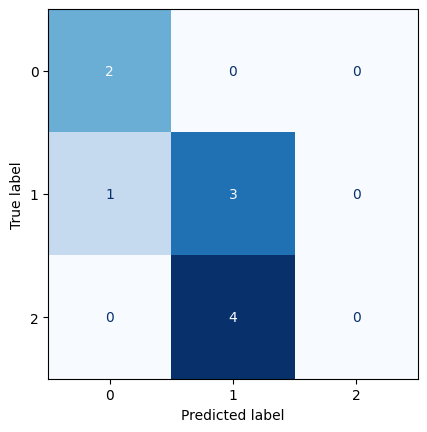

In [21]:
# Avaliações finais
cm = confusion_matrix(y_df_test, y_pred)
acc = accuracy_score(y_df_test, y_pred)
pr = precision_score(y_df_test, y_pred, average="weighted")
recall = recall_score(y_df_test, y_pred, average="weighted")

print("\n=========== Modelo final (XGBoost best params) ===========")
print("Acurácia :", round(acc, 4))
print("Precisão :", round(pr, 4))
print("Recall   :", round(recall, 4), "\n")

ConfusionMatrixDisplay(cm).plot(
    cmap="Blues",
    colorbar=False
);

**Análise:** Após fazer o teste com a base real, vimos que o modelo não desempenhou bem. Ele conseguiu acertar o total de 5 dados, enquanto errou um total de 5 também. O modelo não foi capaz de prever nenhum da classe 2.

- Conclusão
---

Após a realização de todas as etapas de análise exploratória, treinamento e avaliação dos modelos de classificação, conclui-se que, com o volume de dados reais disponíveis, não é possível construir um modelo preditivo confiável para produção.

Os 10 registros reais presentes na base são insuficientes para que qualquer algoritmo de machine learning consiga aprender padrões generalizáveis. O restante dos dados, gerado por LLM, cumpriu um papel exploratório importante, permitindo testar pipelines, validar lógicas e entender o comportamento das variáveis, mas não substitui dados reais para fins de treinamento efetivo.

Mesmo com o uso de técnicas robustas de validação como Leave-One-Out e Stratified K-Fold, ajuste de hiperparâmetros e seleção de features, o modelo esbarra em limitações estruturais que não podem ser contornadas sem mais dados: desbalanceamento entre classes, baixa correlação das features brutas com a target e risco de sobreajuste devido ao tamanho reduzido da amostra.

Portanto, para que este projeto avance para uma etapa de deploy com resultados confiáveis, é necessário coletar um volume maior de dados reais de empresas, garantindo representatividade entre os diferentes níveis de maturidade ESG. Somente a partir disso será possível treinar um modelo com capacidade real de generalização e aplicação prática.
